# 01 — Честный combined: pump (vol-gate + классификатор) + dump, tail-лимиты, реинвест + DCA

В 00 pump был упрощён (без volume-фильтра и классификатора) → per-trade edge
маргинальный, портфель завышен capacity-артефактом. Здесь собираем pump ВЕРНО и
делаем 1+2+3:
1. **pump честно**: +5%/15m **AND** объём>3× медианной минутной (vol-gate),
   scale-in price-step short, + классификатор (walk-forward).
2. **слои на оба**: классификатор-фильтр (pred>0) + tail-лимиты (стоп −20% + KS).
3. **combined портфель с реинвестом** (одна книга, compound 2%/equity).
+ DCA: $100/мес в робота, без вывода → куда придём к 2026.

In [1]:
import sys; sys.path.insert(0,".")
from _lab import *
import numpy as np, pandas as pd
from pathlib import Path
import heapq
from sklearn.ensemble import HistGradientBoostingRegressor
WIN=15;H=240;COOLDOWN=10;N_MAX=10;FEE=0.00075;DELTA=0.02;DAY=1440
THR_D=0.07; THR_P=0.05; VOL_MULT=3.0
FEATN=["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","streak"]

def clusters(c,thr,side):
    if len(c)<WIN+5: return []
    r=np.full(len(c),np.nan); r[WIN:]=c[WIN:]/c[:-WIN]-1
    cond=(r<=-thr) if side<0 else (r>=thr)
    out=[];i=WIN;n=len(c)
    while i<n:
        if not cond[i] or (i>0 and cond[i-1]): i+=1;continue
        st=i;lt=i;f=0;j=i+1
        while j<n:
            if cond[j]: lt=j;f=0
            else:
                f+=1
                if f>=COOLDOWN: break
            j+=1
        out.append((st,lt)); i=lt+COOLDOWN+1
    return out
def fills(c,st,en,side):
    pos=[st];lc=c[st];t=st+1
    while t<=en and len(pos)<N_MAX:
        trig=(c[t]<=lc*(1-DELTA)) if side<0 else (c[t]>=lc*(1+DELTA))
        if trig: pos.append(t);lc=c[t]
        t+=1
    return pos
def feat(c,v,h,l,st,side):
    def ret(k): return c[st]/c[st-k]-1 if st-k>=0 else np.nan
    base=np.median(v[max(0,st-DAY):st]) if st>60 else np.nan
    lr=np.diff(np.log(c[max(0,st-60):st+1]))
    surge15=v[st-14:st+1].sum()/(base*15) if base and base>0 else np.nan
    surge1=v[st]/base if base and base>0 else np.nan
    # streak in the move direction
    s=0;k=st
    if side<0:
        while k>0 and c[k]<c[k-1]: s+=1;k-=1
    else:
        while k>0 and c[k]>c[k-1]: s+=1;k-=1
    return [ret(1),ret(3),ret(5),ret(15),ret(30),ret(60),
            (c[st]/c[st-5]-1)-(c[st-5]/c[st-15]-1 if st-15>=0 else np.nan),
            surge15,surge1, lr.std() if len(lr)>5 else np.nan,
            (h[st-14:st+1].max()-l[st-14:st+1].min())/c[st],
            c[st]/h[max(0,st-DAY):st+1].max()-1, c[st]/l[max(0,st-DAY):st+1].min()-1, s], surge15

In [2]:
# single pass: build BOTH streams with features + price-step pnl + mae(for stop)
def build():
    D=[];P=[]
    for sym in list_symbols():
        try: df=ohlcv(sym,"2024-01-01","2026-07-01","1min")
        except Exception: continue
        c=df["close"].to_numpy("float64");v=df["volume"].to_numpy("float64")
        h=df["high"].to_numpy("float64");l=df["low"].to_numpy("float64");ts=df.index;n=len(c)
        for side,thr,store,gate in [(-1,THR_D,D,False),(+1,THR_P,P,True)]:
            for (st,en) in clusters(c,thr,side):
                ex=en+1+H
                if st<DAY or st+1>=n or ex>=n: continue
                f,surge15=feat(c,v,h,l,st,side)
                if gate and not (surge15>=VOL_MULT): continue   # pump vol-gate
                pos=[p for p in fills(c,st,en,side) if p+1<n]
                pr=np.array([c[p+1] for p in pos]);ws=np.arange(1,len(pr)+1,dtype=float);ws/=ws.sum()
                avg=(ws*pr).sum()
                raw=c[ex]/avg-1
                pnl=(raw if side<0 else -raw)-2*FEE
                seg=c[en+1:ex+1]
                if side<0: mae=(seg.min()/avg-1)            # long worst (down)
                else:      mae=-(seg.max()/avg-1)           # short worst (up) as pnl
                row=dict(entry=ts[st+1],exit_ts=ts[ex],pnl=pnl,mae=mae,
                         **{FEATN[i]:f[i] for i in range(len(FEATN))})
                store.append(row)
    return pd.DataFrame(D),pd.DataFrame(P)
DUMP,PUMP=build()
for nm,X in [("DUMP",DUMP),("PUMP(vol-gated)",PUMP)]:
    X.sort_values("entry",inplace=True); X.reset_index(drop=True,inplace=True)
    print(f"{nm}: {len(X)} trades, raw mean {X.pnl.mean()*100:+.2f}%, win {(X.pnl>0).mean()*100:.1f}%")

DUMP: 4361 trades, raw mean +5.23%, win 71.1%
PUMP(vol-gated): 12034 trades, raw mean -0.08%, win 53.6%


In [3]:
# walk-forward classifier preds + breadth, per stream
def wf_and_breadth(X):
    X=X.dropna().reset_index(drop=True)
    et=X.entry.values.astype("datetime64[ns]").astype("int64"); w=15*60*10**9
    X["breadth"]=np.arange(len(et))-np.searchsorted(et,et-w,side="right")+1
    pred=np.full(len(X),np.nan)
    cuts=[int(len(X)*q) for q in (0.40,0.55,0.70,0.85,1.0)]; prev=cuts[0]
    for cut in cuts[1:]:
        tr=X.iloc[:prev]
        m=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=300,
            l2_regularization=1.0,min_samples_leaf=40,random_state=0)
        m.fit(tr[FEATN],tr.pnl); pred[prev:cut]=m.predict(X.iloc[prev:cut][FEATN]); prev=cut
    X["pred"]=pred
    oos=X[X.pred.notna()]
    return X, np.corrcoef(oos.pred,oos.pnl)[0,1]
DUMP,cD=wf_and_breadth(DUMP); PUMP,cP=wf_and_breadth(PUMP)
print(f"WF OOS corr: dump {cD:+.3f}, pump {cP:+.3f}")

WF OOS corr: dump +0.209, pump +0.079


In [4]:
STOP=0.20; KS=40
def apply_layers(X):
    pnl=np.where(X.mae.values<=-STOP, -STOP-2*FEE, X.pnl.values)
    keep=((X.pred.values>0)|np.isnan(X.pred.values)) & (X.breadth.values<=KS)
    Y=X.copy(); Y["fpnl"]=pnl; Y=Y[keep].reset_index(drop=True)
    return Y
Df=apply_layers(DUMP); Pf=apply_layers(PUMP)
def quick(nm,Y):
    p=Y.fpnl.values
    print(f"  {nm:18} n={len(p):5d}  mean {p.mean()*100:+.2f}%  win {(p>0).mean()*100:4.1f}%  q10 {np.quantile(p,.1)*100:+.2f}%")
print("=== after classifier(pred>0)+stop+KS (per-trade) ===")
quick("DUMP",Df); quick("PUMP(faithful)",Pf)

=== after classifier(pred>0)+stop+KS (per-trade) ===
  DUMP               n= 2129  mean +2.57%  win 62.8%  q10 -7.40%
  PUMP(faithful)     n= 8670  mean +0.69%  win 61.4%  q10 -8.37%


In [5]:
PER0=20.;START=1000.;MAX=50
def daily_curve(eq_t,eq_v,start):
    s=pd.Series(eq_v,index=pd.to_datetime(eq_t)).sort_index()
    s=s[~s.index.duplicated(keep="last")]; return s.resample("1D").last().ffill()
def book(trades, compound=False, dca=0.0, start=START):
    # trades: df with entry, exit_ts, fpnl. dca: $/month added on month starts.
    t=trades.sort_values("entry"); en=t.entry.values.astype("datetime64[ns]")
    ex=t.exit_ts.values.astype("datetime64[ns]"); pnl=t.fpnl.values
    cash=start;dep=0.;openh=[];eq_t=[];eq_v=[];taken=0;contributed=start
    # injection schedule
    months=pd.date_range(pd.Timestamp(en.min()).normalize().replace(day=1),
                         pd.Timestamp(ex.max()),freq="MS") if dca>0 else []
    mi=0; months=list(months)
    for i in range(len(pnl)):
        now=pd.Timestamp(en[i])
        while mi<len(months) and months[mi]<=now:
            cash+=dca; contributed+=dca; eq_t.append(months[mi]); eq_v.append(cash+dep); mi+=1
        while openh and openh[0][0]<=en[i]:
            _,notional,pn=heapq.heappop(openh); cash+=notional*(1+pn); dep-=notional
            eq_t.append(pd.Timestamp(_)); eq_v.append(cash+dep)
        eq=cash+dep; notional=(0.02*eq) if compound else PER0
        if len(openh)<MAX and cash>=notional and notional>0:
            cash-=notional;dep+=notional;heapq.heappush(openh,(ex[i],notional,pnl[i]));taken+=1
    while mi<len(months):
        cash+=dca;contributed+=dca;eq_t.append(months[mi]);eq_v.append(cash+dep);mi+=1
    for _,notional,pn in sorted(openh): cash+=notional*(1+pn);dep-=notional;eq_t.append(pd.Timestamp(_));eq_v.append(cash+dep)
    return daily_curve(eq_t,eq_v,start), cash, contributed, taken
def metrics(eq,contributed):
    r=eq.pct_change().dropna(); span=(eq.index[-1]-eq.index[0]).days/365.25
    sh=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    peak=np.maximum.accumulate(eq.values); dd=(eq.values/peak-1).min()
    return sh,dd,span
# COMBINED book (both streams, reinvest, no DCA) for Sharpe/DD/corr
both=pd.concat([Df[["entry","exit_ts","fpnl"]],Pf[["entry","exit_ts","fpnl"]]]).sort_values("entry")
eC,finC,_,tkC=book(both,compound=True)
eD,finD,_,_=book(Df,compound=True); eP,finP,_,_=book(Pf,compound=True)
shC,ddC,span=metrics(eC,0); shD,ddD,_=metrics(eD,0); shP,ddP,_=metrics(eP,0)
# correlation of daily returns
idx=eD.index.union(eP.index); rD=eD.reindex(idx).ffill().pct_change(); rP=eP.reindex(idx).ffill().pct_change()
cm=rD.dropna().index.intersection(rP.dropna().index)
print("=== faithful streams, reinvest 2%, fixed $1000 (no DCA) ===")
print(f"daily-return corr(dump,pump) = {np.corrcoef(rD.loc[cm],rP.loc[cm])[0,1]:+.3f}\n")
T=pd.DataFrame([
 dict(book="DUMP",final=f"${finD:,.0f}",CAGR=f"{(finD/START)**(1/span)-1:+.1%}",Sharpe=round(shD,2),maxDD=f"{ddD:.1%}"),
 dict(book="PUMP(faithful)",final=f"${finP:,.0f}",CAGR=f"{(finP/START)**(1/span)-1:+.1%}",Sharpe=round(shP,2),maxDD=f"{ddP:.1%}"),
 dict(book="COMBINED",final=f"${finC:,.0f}",CAGR=f"{(finC/START)**(1/span)-1:+.1%}",Sharpe=round(shC,2),maxDD=f"{ddC:.1%}"),
])
print(T.to_string(index=False))

=== faithful streams, reinvest 2%, fixed $1000 (no DCA) ===
daily-return corr(dump,pump) = -0.502

          book   final    CAGR  Sharpe  maxDD
          DUMP  $2,550  +49.6%    1.97 -10.6%
PUMP(faithful)  $3,818  +78.0%    3.75 -11.1%
      COMBINED $11,504 +186.0%    5.04  -9.5%


In [6]:
# ===== DCA: $100/month into the combined robot, no withdrawals =====
DCA=100.0
eDCA,finDCA,contrib,tk=book(both,compound=True,dca=DCA,start=0.0)
# baseline: same contributions into nothing (cash)
months=pd.date_range(eDCA.index.min().replace(day=1),eDCA.index.max(),freq="MS")
cash_only=float(len(months))*DCA
print("=== DCA $100/month into pump_dump robot (reinvested, to 2026) ===")
print(f"  months contributed:        {len(months)}")
print(f"  total contributed:         ${contrib:,.0f}")
print(f"  FINAL value (robot):       ${finDCA:,.0f}")
print(f"  if kept as cash:           ${cash_only:,.0f}")
print(f"  profit over contributions: ${finDCA-contrib:+,.0f}  ({(finDCA/contrib-1)*100:+.0f}% on money in)")
print(f"  growth multiple:           {finDCA/cash_only:.2f}x vs cash")

=== DCA $100/month into pump_dump robot (reinvested, to 2026) ===
  months contributed:        28
  total contributed:         $2,800
  FINAL value (robot):       $12,205
  if kept as cash:           $2,800
  profit over contributions: $+9,405  (+336% on money in)
  growth multiple:           4.36x vs cash


[saved] notebooks\pump_dump_combined\_out\comb_01_dca.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_01_dca.png')

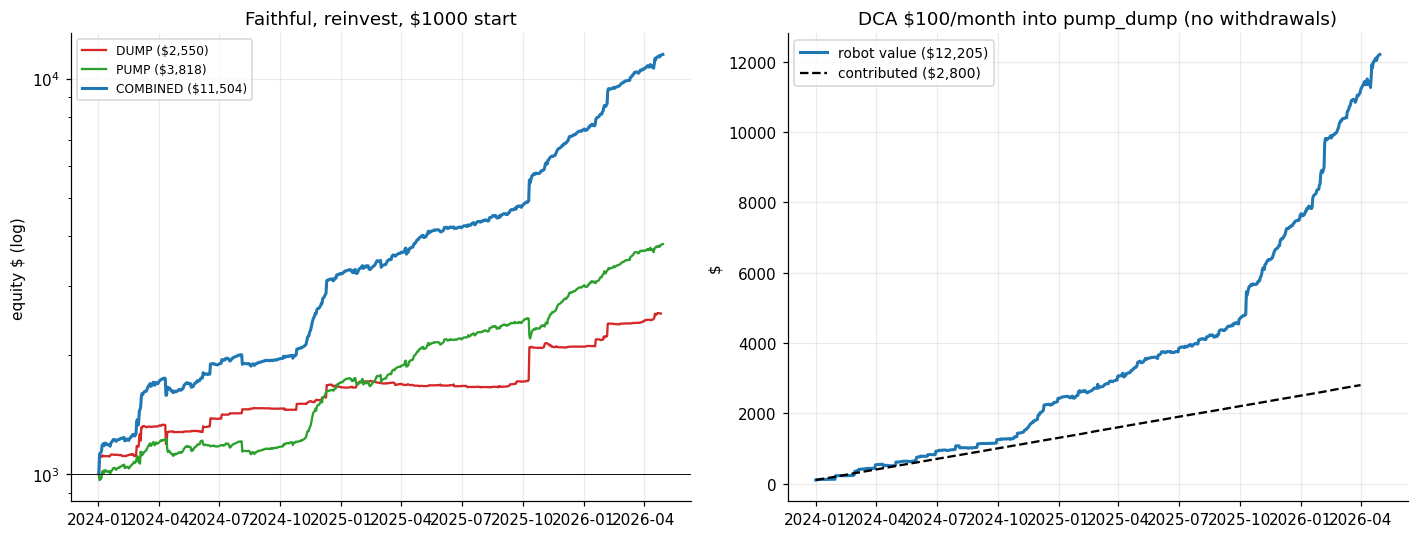

In [7]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].plot(eD.index,eD.values,label=f"DUMP (${finD:,.0f})",color="#d62728")
ax[0].plot(eP.index,eP.values,label=f"PUMP (${finP:,.0f})",color="#2ca02c")
ax[0].plot(eC.index,eC.values,label=f"COMBINED (${finC:,.0f})",color="#1f77b4",lw=2)
ax[0].set_yscale("log");ax[0].axhline(START,color="k",lw=.6);ax[0].set_title("Faithful, reinvest, $1000 start")
ax[0].legend(fontsize=8);ax[0].set_ylabel("equity $ (log)")
# DCA curve + contributions staircase
months=pd.date_range(eDCA.index.min().replace(day=1),eDCA.index.max(),freq="MS")
contrib_line=pd.Series([DCA*(i+1) for i in range(len(months))],index=months)
ax[1].plot(eDCA.index,eDCA.values,color="#1f77b4",lw=2,label=f"robot value (${finDCA:,.0f})")
ax[1].plot(contrib_line.index,contrib_line.values,color="k",ls="--",label=f"contributed (${contrib:,.0f})")
ax[1].set_title("DCA $100/month into pump_dump (no withdrawals)");ax[1].set_ylabel("$");ax[1].legend(fontsize=9)
show("comb_01_dca")

## Как читать
- **per-trade после слоёв** — теперь pump с vol-gate+классификатором должен иметь
  реальный (не +0.02%) edge; сравни с dump.
- **Таблица книг** — combined Sharpe выше каждого, DD ниже (диверсификация на
  ЧЕСТНЫХ стримах).
- **DCA** — синяя кривая (стоимость робота) vs чёрный пунктир (сколько внесено).
  Разрыв = заработок сложного процента на регулярных взносах к 2026.

*Verdict после прогона. Оговорки: хвост вне выборки, стоп close-based, live=0.*

## VERDICT (combined 01)

**Pump собран честно (vol-gate + классификатор, WF).** Vol-gate сам по себе raw-edge
не спас (−0.08%/сделку); работу делает КЛАССИФИКАТОР: после pred>0+стоп+KS pump
= +0.69%/сделку win 61% (OOS corr тонкая +0.079 → хрупко). DUMP после слоёв +2.57%.
Корреляция дневных −0.50.

Книги (реинвест 2%, $1000): DUMP $2550/CAGR49.6%/Sh1.97/DD−10.6%; PUMP $3818/78%/3.75/
−11.1%; **COMBINED $11504/CAGR186%/Sharpe5.04/DD−9.5%**. DCA $100/мес×28=$2800 →
робот $12205 (+336% на вложенное, 4.36× кэша).

**ЧЕСТНЫЙ ФЛАГ:**
- РОБАСТНО: corr −0.50, regime-хедж, combined Sharpe>>каждого, DD ниже —
  диверсификация объективна. ГЛАВНЫЙ вывод.
- ОПТИМИСТИЧНО (не верить абсолюту): CAGR186%/4.36× завышены — 2%-реинвест ×10800
  сделок = взрывной compound; предполагает бесконечную ёмкость/делимость (микрокапы
  срежут); pump-edge на тонком классификаторе (+0.079) хрупок; Sharpe5 нереалистичен
  live. Форма DCA верна, множитель — оптимистичный потолок.

**Дальше:** реалистичная ёмкость/слиппедж + де-рейт sizing → believable абсолют;
анти-overfit пампа (вол-гейт+фичи); порт в бота.